<a href="https://colab.research.google.com/github/shoopy7/shoopy7/blob/main/NonProfitProgramEval_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objectives of this practice project

Collect → Clean → Validate → Analyze → Visualize → Tell the Story



#load libraries (adv ml, cv)

In [1]:
#Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
#import plotly.express as px #3d interactive graphs can save as html and put on websites

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)
# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# Library to split data
from sklearn.model_selection import train_test_split

# To perform statistical analysis
import scipy.stats as stats

# To impute missing values
from sklearn.impute import SimpleImputer


#Load and copy data set and mount Google drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# load data sets
participants_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/projects for potential jobs or to showcase practice skills/NonProfit Program Evaluation Practice/participant_enrollment.csv')
attendance_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/projects for potential jobs or to showcase practice skills/NonProfit Program Evaluation Practice/attendance.csv")
survey_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/projects for potential jobs or to showcase practice skills/NonProfit Program Evaluation Practice/survey_results.csv")
outcomes_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/projects for potential jobs or to showcase practice skills/NonProfit Program Evaluation Practice/academic_outcomes.csv")

In [4]:
# copying data to another varaible to avoid any changes to original data
participants = participants_data.copy()
attendance = attendance_data.copy()
survey = survey_data.copy()
outcomes = outcomes_data.copy()


#data overview, sanity checks, statistical summary, observations

##overview

In [5]:
participants.shape

(15, 8)

In [6]:
attendance.shape

(24, 7)

In [7]:
survey.shape

(16, 7)

In [8]:
outcomes.shape

(10, 7)

In [9]:
participants.head()

,participant_id,name,birth_date,program,enrollment_date,status,gender,school
0,101,Jane Smith,3/2/2010,Tutoring,8/15/24,Active,F,West HS
1,102,J Smith,2010-03-02,tutoring,8-15-2024,Active,F,West High School
2,103,Marcus Lee,NaN,Mentor Program,09/01/24,Active,M,Central HS
3,104,Sarah Johnson,7/15/2009,Mentoring,9/5/24,active,F,East HS
4,105,Michael Brown,2008/12/03,Workforce Readiness,09-15-2024,Active,M,North HS


In [10]:
attendance.head()

,participant_id,session_date,attended,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,101,1/5/25,Yes,NaN,NaN,NaN,NaN
1,101,2025-01-12,Y,NaN,NaN,NaN,NaN
2,101,1-19-25,TRUE,NaN,NaN,NaN,NaN
3,102,1/5/25,Yes,NaN,NaN,NaN,NaN
4,102,1/12/25,N,NaN,NaN,NaN,NaN


In [11]:
survey.head()

,participant_id,survey_type,confidence,school_engagement,career_readiness,Unnamed: 5,Unnamed: 6
0,101,Pre,2,3,1.000,NaN,NaN
1,101,Post,4,4,3.000,NaN,NaN
2,102,Pre,3,2,2.000,NaN,NaN
3,102,Post,4,3,3.000,NaN,NaN
4,103,Pre,1,2,1.000,NaN,NaN


In [12]:
outcomes.head()

,participant_id,pre_gpa,post_gpa,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,101,2.5,3.100,NaN,NaN,NaN,NaN
1,102,"2,7",3.000,NaN,NaN,NaN,NaN
2,103,1.8,2.900,NaN,NaN,NaN,NaN
3,104,3.2,3.500,NaN,NaN,NaN,NaN
4,105,2.4,2.600,NaN,NaN,NaN,NaN


In [13]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   participant_id   15 non-null     int64 
 1   name             15 non-null     object
 2   birth_date       12 non-null     object
 3   program          15 non-null     object
 4   enrollment_date  15 non-null     object
 5   status           15 non-null     object
 6   gender           15 non-null     object
 7   school           15 non-null     object
dtypes: int64(1), object(7)
memory usage: 1.1+ KB


In [14]:
attendance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   participant_id  24 non-null     int64  
 1   session_date    24 non-null     object 
 2   attended        24 non-null     object 
 3   Unnamed: 3      0 non-null      float64
 4   Unnamed: 4      0 non-null      float64
 5   Unnamed: 5      0 non-null      float64
 6   Unnamed: 6      0 non-null      float64
dtypes: float64(4), int64(1), object(2)
memory usage: 1.4+ KB


In [15]:
survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   participant_id     16 non-null     int64  
 1   survey_type        16 non-null     object 
 2   confidence         16 non-null     object 
 3   school_engagement  16 non-null     int64  
 4   career_readiness   15 non-null     float64
 5   Unnamed: 5         0 non-null      float64
 6   Unnamed: 6         0 non-null      float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.0+ KB


In [16]:
outcomes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   participant_id  10 non-null     int64  
 1   pre_gpa         10 non-null     object 
 2   post_gpa        9 non-null      float64
 3   Unnamed: 3      0 non-null      float64
 4   Unnamed: 4      0 non-null      float64
 5   Unnamed: 5      0 non-null      float64
 6   Unnamed: 6      0 non-null      float64
dtypes: float64(5), int64(1), object(1)
memory usage: 692.0+ bytes


In [17]:
participants.duplicated().sum()

np.int64(0)

In [18]:
attendance.duplicated().sum()

np.int64(0)

In [19]:
survey.duplicated().sum()

np.int64(0)

In [20]:
outcomes.duplicated().sum()

np.int64(0)

In [21]:
# Check for missing values WITH COOL VISUAL GRAPH
participants_na = (participants.isna()
                    .sum()
                    .reset_index()
                    .sort_values(0, ascending=False)
                ).rename(columns={'index':'col',0:'na'})

participants_na['percentage_na'] = (participants_na['na'] / len(participants)).round(2)

participants_na.style.background_gradient()


,col,na,percentage_na
2,birth_date,3,0.200000
0,participant_id,0,0.000000
1,name,0,0.000000
3,program,0,0.000000
4,enrollment_date,0,0.000000
5,status,0,0.000000
6,gender,0,0.000000
7,school,0,0.000000


There are 3 missing birth dates

In [22]:
attendance_na = (attendance.isna()
                    .sum()
                    .reset_index()
                    .sort_values(0, ascending=False)
                ).rename(columns={'index':'col',0:'na'})

attendance_na['percentage_na'] = (attendance_na['na'] / len(attendance)).round(2)

attendance_na.style.background_gradient()

,col,na,percentage_na
5,Unnamed: 5,24,1.000000
4,Unnamed: 4,24,1.000000
3,Unnamed: 3,24,1.000000
6,Unnamed: 6,24,1.000000
2,attended,0,0.000000
0,participant_id,0,0.000000
1,session_date,0,0.000000


There are extra columns with no values to be dropped

In [23]:
survey_na = (survey.isna()
                    .sum()
                    .reset_index()
                    .sort_values(0, ascending=False)
                ).rename(columns={'index':'col',0:'na'})

survey_na['percentage_na'] = (survey_na['na'] / len(survey)).round(2)

survey_na.style.background_gradient()

,col,na,percentage_na
6,Unnamed: 6,16,1.000000
5,Unnamed: 5,16,1.000000
4,career_readiness,1,0.060000
2,confidence,0,0.000000
1,survey_type,0,0.000000
0,participant_id,0,0.000000
3,school_engagement,0,0.000000


There are extra columns with no values to be dropped

In [24]:
outcomes_na = (outcomes.isna()
                    .sum()
                    .reset_index()
                    .sort_values(0, ascending=False)
                ).rename(columns={'index':'col',0:'na'})

outcomes_na['percentage_na'] = (outcomes_na['na'] / len(outcomes)).round(2)

outcomes_na.style.background_gradient()

,col,na,percentage_na
5,Unnamed: 5,10,1.000000
4,Unnamed: 4,10,1.000000
3,Unnamed: 3,10,1.000000
6,Unnamed: 6,10,1.000000
2,post_gpa,1,0.100000
1,pre_gpa,0,0.000000
0,participant_id,0,0.000000


There are extra columns with no values to be dropped

In [25]:
# checking for unique values
participants.nunique()


,0
participant_id,15
name,14
birth_date,12
program,9
enrollment_date,15
status,5
gender,2
school,8


* it is of note that there are 5 different values for status
* there are 15 participants, but 14 unique names
* there are 3 missing birthdates
* 8 schools are represented in the data set

In [26]:
attendance.nunique()

,0
participant_id,8
session_date,13
attended,7
Unnamed: 3,0
Unnamed: 4,0
Unnamed: 5,0
Unnamed: 6,0


In [27]:
survey.nunique()

,0
participant_id,8
survey_type,2
confidence,8
school_engagement,4
career_readiness,4
Unnamed: 5,0
Unnamed: 6,0


In [28]:
outcomes.nunique()

,0
participant_id,10
pre_gpa,10
post_gpa,8
Unnamed: 3,0
Unnamed: 4,0
Unnamed: 5,0
Unnamed: 6,0


In [29]:
# Check for missing values in a row and save as a variable

missing_rows_parts = participants[participants.isnull().any(axis=1)]

# Display rows with missing values
#print(missing_rows)
missing_rows_parts


,participant_id,name,birth_date,program,enrollment_date,status,gender,school
2,103,Marcus Lee,NaN,Mentor Program,09/01/24,Active,M,Central HS
7,108,Lisa Martinez,NaN,Tutoring Program,10/15/24,Active,F,West HS
13,114,Tyler Moore,NaN,Tutoring,11/20/24,Active,M,Central High


In [30]:
missing_rows_attend = attendance[attendance.isnull().any(axis=1)]

# Display rows with missing values
#print(missing_rows)
missing_rows_attend

,participant_id,session_date,attended,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,101,1/5/25,Yes,NaN,NaN,NaN,NaN
1,101,2025-01-12,Y,NaN,NaN,NaN,NaN
2,101,1-19-25,TRUE,NaN,NaN,NaN,NaN
3,102,1/5/25,Yes,NaN,NaN,NaN,NaN
4,102,1/12/25,N,NaN,NaN,NaN,NaN
5,102,1/19/25,No,NaN,NaN,NaN,NaN
6,103,2025/01/05,TRUE,NaN,NaN,NaN,NaN
7,103,2025/01/12,TRUE,NaN,NaN,NaN,NaN
8,103,2025/01/19,TRUE,NaN,NaN,NaN,NaN
9,104,1/5/25,Y,NaN,NaN,NaN,NaN


In [31]:
missing_rows_surv = survey[survey.isnull().any(axis=1)]

# Display rows with missing values
#print(missing_rows)
missing_rows_surv

,participant_id,survey_type,confidence,school_engagement,career_readiness,Unnamed: 5,Unnamed: 6
0,101,Pre,2,3,1.000,NaN,NaN
1,101,Post,4,4,3.000,NaN,NaN
2,102,Pre,3,2,2.000,NaN,NaN
3,102,Post,4,3,3.000,NaN,NaN
4,103,Pre,1,2,1.000,NaN,NaN
5,103,Post,5,5,4.000,NaN,NaN
6,104,Pre,4,4,3.000,NaN,NaN
7,104,Post,5,5,4.000,NaN,NaN
8,105,Pre,2,3,NaN,NaN,NaN
9,105,Post,3,4,2.000,NaN,NaN


In [32]:
missing_rows_out = outcomes[outcomes.isnull().any(axis=1)]

# Display rows with missing values

missing_rows_out

,participant_id,pre_gpa,post_gpa,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,101,2.5,3.100,NaN,NaN,NaN,NaN
1,102,"2,7",3.000,NaN,NaN,NaN,NaN
2,103,1.8,2.900,NaN,NaN,NaN,NaN
3,104,3.2,3.500,NaN,NaN,NaN,NaN
4,105,2.4,2.600,NaN,NaN,NaN,NaN
5,106,3.0,3.800,NaN,NaN,NaN,NaN
6,107,2.1,2.000,NaN,NaN,NaN,NaN
7,108,2.9,3.400,NaN,NaN,NaN,NaN
8,109,3.1,NaN,NaN,NaN,NaN,NaN
9,110,300,3.500,NaN,NaN,NaN,NaN


##statisctical summary (numeric and catagorical)

In [33]:
# summary statistics of numeric variables, transposed
participants.describe().T

,count,mean,std,min,25%,50%,75%,max
participant_id,15.000,108.000,4.472,101.000,104.500,108.000,111.500,115.000


In [34]:
attendance.describe().T

,count,mean,std,min,25%,50%,75%,max
participant_id,24.000,104.500,2.341,101.000,102.750,104.500,106.250,108.000
Unnamed: 3,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unnamed: 4,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unnamed: 5,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unnamed: 6,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
survey.describe().T

,count,mean,std,min,25%,50%,75%,max
participant_id,16.000,104.500,2.366,101.000,102.750,104.500,106.250,108.000
school_engagement,16.000,3.375,1.088,2.000,2.750,3.000,4.000,5.000
career_readiness,15.000,2.467,1.187,1.000,1.500,2.000,3.500,4.000
Unnamed: 5,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unnamed: 6,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
outcomes.describe().T

,count,mean,std,min,25%,50%,75%,max
participant_id,10.000,105.500,3.028,101.000,103.250,105.500,107.750,110.000
post_gpa,9.000,3.089,0.549,2.000,2.900,3.100,3.500,3.800
Unnamed: 3,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unnamed: 4,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unnamed: 5,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unnamed: 6,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Audit

### Data Quality Issues Found
* Missing birth dates
* Invalid birth dates??
* Program naming inconsistencies
* Status inconsistencies
* School naming inconsistencies

####participants data set
* 15 rows and 8 columns
* all 15 rows are unique particiapnts
* 3 participants are missing birth dates and all 3 are enrolled in a high school
  * If we are unable to obtain the student's birthday, we will average the highs school participants ages and impute this value
* inconsistencies in data entry for the following columns:
  * name
  * birthdate
  * program
  * enrollment date
  * status
  * school
* here appears to be a duplicate entry, J Smith/Jane Smith, both with the same birthday; PENDING REVIEW

####attendance data set
* 24 rows and 7 columns
* 4 columns do not contain data and are unnamed; to be dropped
* inconsistent columns of data
  * session date
  * attendance

####survey data set
* 16 rows and 7 columns
* 2 columns appear to not contain data; to be dropped
* 1 values is missing for career rediness; if this value cannot be obtained, an average of the career readiness column will be imputed for this missing value

#### outcomes data set
* 10 rows, 7 columns
* 4 columns appear not to contain data; to be dropped
* 1 value is missing for post-gpa; if this value cannot be obtained, an average of the of the post-gra column will be imputed for this missing value
* the pre-gra column appears to have a missing value

#modify data sets

###participants data set

In [37]:
# show entire data set
participants


,participant_id,name,birth_date,program,enrollment_date,status,gender,school
0,101,Jane Smith,3/2/2010,Tutoring,8/15/24,Active,F,West HS
1,102,J Smith,2010-03-02,tutoring,8-15-2024,Active,F,West High School
2,103,Marcus Lee,NaN,Mentor Program,09/01/24,Active,M,Central HS
3,104,Sarah Johnson,7/15/2009,Mentoring,9/5/24,active,F,East HS
4,105,Michael Brown,2008/12/03,Workforce Readiness,09-15-2024,Active,M,North HS
5,106,Emily Davis,04/20/2010,workforce readiness,09/15/24,ACTIVE,F,North High
6,107,Chris Wilson,2011-11-11,Tutoring,10/1/24,Withdrawn,M,Central HS
7,108,Lisa Martinez,NaN,Tutoring Program,10/15/24,Active,F,West HS
8,109,Robert Garcia,2010-06-30,Mentor Program,10/20/24,Active,M,East HS
9,110,Amanda White,5/5/2009,Mentoring,11/01/24,Active,F,East High School


Participant 101 & 102 appear to be duplicates.  However, both participant numbers are used throughout the data sets.  Further reviews required by ADMIN

In [38]:
participants[
    participants["participant_id"].isin([101,102])
]

,participant_id,name,birth_date,program,enrollment_date,status,gender,school
0,101,Jane Smith,3/2/2010,Tutoring,8/15/24,Active,F,West HS
1,102,J Smith,2010-03-02,tutoring,8-15-2024,Active,F,West High School


In [39]:
attendance[
    attendance["participant_id"].isin([101,102])
]

,participant_id,session_date,attended,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,101,1/5/25,Yes,NaN,NaN,NaN,NaN
1,101,2025-01-12,Y,NaN,NaN,NaN,NaN
2,101,1-19-25,TRUE,NaN,NaN,NaN,NaN
3,102,1/5/25,Yes,NaN,NaN,NaN,NaN
4,102,1/12/25,N,NaN,NaN,NaN,NaN
5,102,1/19/25,No,NaN,NaN,NaN,NaN


In [40]:
survey[
    survey["participant_id"].isin([101,102])
]

,participant_id,survey_type,confidence,school_engagement,career_readiness,Unnamed: 5,Unnamed: 6
0,101,Pre,2,3,1.000,NaN,NaN
1,101,Post,4,4,3.000,NaN,NaN
2,102,Pre,3,2,2.000,NaN,NaN
3,102,Post,4,3,3.000,NaN,NaN


In [41]:
outcomes[
    outcomes["participant_id"].isin([101,102])
]

,participant_id,pre_gpa,post_gpa,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,101,2.5,3.100,NaN,NaN,NaN,NaN
1,102,"2,7",3.000,NaN,NaN,NaN,NaN


When looking at attendance for 1/12/2025, survey data, and outcomes data, it appears that these are 2 unique participants.


It is my recommendation at this time to keep both participant ids in the data sets.  

Further REVIEW by ADMIN in needed to see if the name and birthday data needs modification.

In [42]:
participants["program"].value_counts(dropna=False)

,count
program,
Tutoring,4
Mentor Program,2
Mentoring,2
Workforce Readiness,2
tutoring,1
workforce readiness,1
Tutoring Program,1
Work Readiness,1
Mentoring Program,1


In [43]:
# Standardize Program Names
participants["program"] = (
    participants["program"]
    .str.lower()
    .str.strip()
)

In [44]:
# map values
program_map = {
    "tutoring": "Tutoring",
    "tutoring program": "Tutoring",
    "mentor program": "Mentoring",
    "mentoring": "Mentoring",
    "mentoring program": "Mentoring",
    "work readiness": "Workforce Readiness",
    "workforce readiness": "Workforce Readiness"
}

In [45]:
# apply mapping to dataframe
participants["program"] = (
    participants["program"]
    .replace(program_map)
)

In [46]:
participants["program"].value_counts(dropna=False)

,count
program,
Tutoring,6
Mentoring,5
Workforce Readiness,4


Cleaned 'program' column

In [47]:
participants["status"].value_counts(dropna=False)

,count
status,
Active,11
active,1
ACTIVE,1
Withdrawn,1
Pending,1


In [48]:
# Standardize State Names
participants["status"] = (
    participants["status"]
    .str.lower()
    .str.strip()
)

In [49]:
participants["status"].value_counts(dropna=False)

,count
status,
active,13
withdrawn,1
pending,1


In [50]:
participants["school"].value_counts(dropna=False)

,count
school,
West HS,3
East HS,3
North HS,3
Central HS,2
West High School,1
North High,1
East High School,1
Central High,1


In [51]:
participants["school"] = participants["school"].str.replace(
    r"^(.*)\sHigh$",
    r"\1 High School",
    regex=True
)

In [52]:
# Use Regex For school standardization
participants["school"] = participants["school"].str.replace(
    r"\bHS\b",
    "High School",
    regex=True
)

In [53]:
participants["school"].value_counts(dropna=False)

,count
school,
West High School,4
East High School,4
North High School,4
Central High School,3


In [54]:
participants.columns

Index(['participant_id', 'name', 'birth_date', 'program', 'enrollment_date',
       'status', 'gender', 'school'],
      dtype='object')

In [55]:
participants["birth_date"]

,birth_date
0,3/2/2010
1,2010-03-02
2,NaN
3,7/15/2009
4,2008/12/03
5,04/20/2010
6,2011-11-11
7,NaN
8,2010-06-30
9,5/5/2009


In [56]:
# participants["birth_date"] = pd.to_datetime(
#     participants["birth_date"],
#     errors="coerce"
# )

participants["birth_date"] = pd.to_datetime(
    participants["birth_date"],
    errors="coerce",
    format="mixed"
)

In [57]:
participants["birth_date"]

,birth_date
0,2010-03-02
1,2010-03-02
2,NaT
3,2009-07-15
4,2008-12-03
5,2010-04-20
6,2011-11-11
7,NaT
8,2010-06-30
9,2009-05-05


In [58]:
participants[
    participants["birth_date"].isna()
]

,participant_id,name,birth_date,program,enrollment_date,status,gender,school
2,103,Marcus Lee,NaT,Mentoring,09/01/24,active,M,Central High School
7,108,Lisa Martinez,NaT,Tutoring,10/15/24,active,F,West High School
11,112,David Thomas,NaT,Workforce Readiness,11/10/24,active,M,North High School
13,114,Tyler Moore,NaT,Tutoring,11/20/24,active,M,Central High School


In [59]:
# participants["birth_date"] = participants[
#     "birth_date"
# ].dt.strftime("%Y-%m-%d")

In [60]:
participants["birth_date"]

,birth_date
0,2010-03-02
1,2010-03-02
2,NaT
3,2009-07-15
4,2008-12-03
5,2010-04-20
6,2011-11-11
7,NaT
8,2010-06-30
9,2009-05-05


In [61]:
participants["birth_date"].isnull().sum()

np.int64(4)

An additional missing values included becuase 2/31/2010 is not a valid calendar date.

In [62]:
participants["enrollment_date"]

,enrollment_date
0,8/15/24
1,8-15-2024
2,09/01/24
3,9/5/24
4,09-15-2024
5,09/15/24
6,10/1/24
7,10/15/24
8,10/20/24
9,11/01/24


In [63]:
# participants["enrollment_date"] = pd.to_datetime(
#     participants["enrollment_date"],
#     errors="coerce"
# )

participants["enrollment_date"] = pd.to_datetime(
    participants["enrollment_date"],
    errors="coerce",
    format="mixed"
)

In [64]:
# participants["enrollment_date"] = participants[
#     "enrollment_date"
# ].dt.strftime("%Y-%m-%d")

In [65]:
participants["enrollment_date"]

,enrollment_date
0,2024-08-15
1,2024-08-15
2,2024-09-01
3,2024-09-05
4,2024-09-15
5,2024-09-15
6,2024-10-01
7,2024-10-15
8,2024-10-20
9,2024-11-01


In [66]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   participant_id   15 non-null     int64         
 1   name             15 non-null     object        
 2   birth_date       11 non-null     datetime64[ns]
 3   program          15 non-null     object        
 4   enrollment_date  15 non-null     datetime64[ns]
 5   status           15 non-null     object        
 6   gender           15 non-null     object        
 7   school           15 non-null     object        
dtypes: datetime64[ns](2), int64(1), object(5)
memory usage: 1.1+ KB


In [68]:
participants["birth_date"].isna().sum()

np.int64(4)

In [69]:
participants["enrollment_date"].isna().sum()

np.int64(0)

###attendance data set

In [70]:
# # drop ID column as it is not a determining factor for a model
# df = df.drop('ID',axis=1)
# participants = participants.drop('ID',axis=1)

In [71]:
attendance.columns

Index(['participant_id', 'session_date', 'attended', 'Unnamed: 3',
       'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6'],
      dtype='object')

In [72]:
attendance = attendance.loc[
    :, ~attendance.columns.str.contains("^Unnamed")
]

In [73]:
attendance.columns

Index(['participant_id', 'session_date', 'attended'], dtype='object')

In [74]:
attendance["attended"].unique()

array(['Yes', 'Y', 'TRUE', 'N', 'No', 'Missing', 'FALSE'], dtype=object)

In [75]:
attendance_map = {
    "Yes": "Yes",
    "Y": "Yes",
    "TRUE": "Yes",

    "No": "No",
    "N": "No",
    "FALSE": "No",

    "Missing": "Unknown"
}

In [76]:
attendance["attended"] = attendance["attended"].replace(attendance_map)

In [77]:
attendance["attended"].value_counts(dropna=False)

,count
attended,
Yes,16
No,7
Unknown,1


In [78]:
attendance["attendance_binary"] = attendance["attended"].map({
    "Yes": 1,
    "No": 0
})

In [79]:
attendance.head(2)

,participant_id,session_date,attended,attendance_binary
0,101,1/5/25,Yes,1.000
1,101,2025-01-12,Yes,1.000


In [80]:
attendance.groupby("participant_id")[
    "attendance_binary"
].sum()

,attendance_binary
participant_id,
101,3.000
102,1.000
103,3.000
104,3.000
105,1.000
106,2.000
107,0.000
108,3.000


Attendance Data Quality Finding

Issue:
Attendance values were entered inconsistently.

Examples:
- Yes
- Y
- TRUE
- No
- N
- FALSE
- Missing

Action:
Standardized attendance values to:
- Yes
- No
- Unknown

Result:
Attendance reporting can now be calculated consistently.

In [81]:
attendance["session_date"].unique()

array(['1/5/25', '2025-01-12', '1-19-25', '1/12/25', '1/19/25',
       '2025/01/05', '2025/01/12', '2025/01/19', '01-05-2025',
       '01-12-2025', '01-19-2025', '2025-01-05', '2025-01-19'],
      dtype=object)

In [82]:
attendance["session_date"] = pd.to_datetime(
    attendance["session_date"],
    errors="coerce",
    format="mixed"
)

In [83]:
attendance["session_date"].head()

,session_date
0,2025-01-05
1,2025-01-12
2,2025-01-19
3,2025-01-05
4,2025-01-12


In [84]:
attendance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   participant_id     24 non-null     int64         
 1   session_date       24 non-null     datetime64[ns]
 2   attended           24 non-null     object        
 3   attendance_binary  23 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 900.0+ bytes


In [85]:
attendance["session_date"].isna().sum()

np.int64(0)

In [86]:
attendance.sort_values(["participant_id", "session_date"]).head(15)

,participant_id,session_date,attended,attendance_binary
0,101,2025-01-05,Yes,1.000
1,101,2025-01-12,Yes,1.000
2,101,2025-01-19,Yes,1.000
3,102,2025-01-05,Yes,1.000
4,102,2025-01-12,No,0.000
5,102,2025-01-19,No,0.000
6,103,2025-01-05,Yes,1.000
7,103,2025-01-12,Yes,1.000
8,103,2025-01-19,Yes,1.000
9,104,2025-01-05,Yes,1.000


In [87]:
attendance["session_date"].value_counts().sort_index()

,count
session_date,
2025-01-05,8
2025-01-12,8
2025-01-19,8


In [88]:
attendance


,participant_id,session_date,attended,attendance_binary
0,101,2025-01-05,Yes,1.000
1,101,2025-01-12,Yes,1.000
2,101,2025-01-19,Yes,1.000
3,102,2025-01-05,Yes,1.000
4,102,2025-01-12,No,0.000
5,102,2025-01-19,No,0.000
6,103,2025-01-05,Yes,1.000
7,103,2025-01-12,Yes,1.000
8,103,2025-01-19,Yes,1.000
9,104,2025-01-05,Yes,1.000


###survey data set

In [89]:
survey

,participant_id,survey_type,confidence,school_engagement,career_readiness,Unnamed: 5,Unnamed: 6
0,101,Pre,2,3,1.000,NaN,NaN
1,101,Post,4,4,3.000,NaN,NaN
2,102,Pre,3,2,2.000,NaN,NaN
3,102,Post,4,3,3.000,NaN,NaN
4,103,Pre,1,2,1.000,NaN,NaN
5,103,Post,5,5,4.000,NaN,NaN
6,104,Pre,4,4,3.000,NaN,NaN
7,104,Post,5,5,4.000,NaN,NaN
8,105,Pre,2,3,NaN,NaN,NaN
9,105,Post,3,4,2.000,NaN,NaN


In [90]:
survey.columns

Index(['participant_id', 'survey_type', 'confidence', 'school_engagement',
       'career_readiness', 'Unnamed: 5', 'Unnamed: 6'],
      dtype='object')

In [91]:
survey = survey.loc[
    :, ~survey.columns.str.contains("^Unnamed")
]

In [92]:
survey.columns

Index(['participant_id', 'survey_type', 'confidence', 'school_engagement',
       'career_readiness'],
      dtype='object')

In [93]:
survey["career_readiness"].value_counts()

,count
career_readiness,
1.000,4
2.000,4
4.000,4
3.000,3


In [94]:
survey['confidence'].value_counts()


,count
confidence,
2,4
4,3
5,3
3,2
1,1
Five,1
3.0,1
4.0,1


In [95]:
survey["confidence"].unique()

array(['2', '4', '3', '1', '5', 'Five', '3.0', '4.0'], dtype=object)

In [96]:
survey["confidence"] = survey["confidence"].replace({
    "Five": 5
})

/tmp/ipykernel_955/254416785.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  survey["confidence"] = survey["confidence"].replace({


In [97]:
survey["confidence"] = pd.to_numeric(
    survey["confidence"],
    errors="coerce"
)

/tmp/ipykernel_955/2278655904.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  survey["confidence"] = pd.to_numeric(


In [98]:
survey["confidence"].value_counts(dropna=False)

,count
confidence,
2.000,4
4.000,4
5.000,4
3.000,3
1.000,1


In [99]:
survey["confidence"].describe()

,confidence
count,16.000
mean,3.375
std,1.310
min,1.000
25%,2.000
50%,3.500
75%,4.250
max,5.000


Survey Confidence Variable

Issue:
Confidence responses were stored inconsistently.

Examples:
- 5
- Five
- 3.0
- 4.0

Action:
Standardized all responses to numeric values.

Result:
Confidence variable now contains a consistent 1–5 scale suitable for analysis.

In [100]:
survey["school_engagement"].value_counts(dropna=False)

,count
school_engagement,
3,5
4,4
2,4
5,3


In [101]:
survey["career_readiness"].value_counts(dropna=False)

,count
career_readiness,
1.000,4
2.000,4
4.000,4
3.000,3
NaN,1


###outcomes data set

In [102]:
outcomes

,participant_id,pre_gpa,post_gpa,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,101,2.5,3.100,NaN,NaN,NaN,NaN
1,102,"2,7",3.000,NaN,NaN,NaN,NaN
2,103,1.8,2.900,NaN,NaN,NaN,NaN
3,104,3.2,3.500,NaN,NaN,NaN,NaN
4,105,2.4,2.600,NaN,NaN,NaN,NaN
5,106,3.0,3.800,NaN,NaN,NaN,NaN
6,107,2.1,2.000,NaN,NaN,NaN,NaN
7,108,2.9,3.400,NaN,NaN,NaN,NaN
8,109,3.1,NaN,NaN,NaN,NaN,NaN
9,110,300,3.500,NaN,NaN,NaN,NaN


In [103]:
outcomes.columns

Index(['participant_id', 'pre_gpa', 'post_gpa', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6'],
      dtype='object')

In [104]:
outcomes = outcomes.loc[
    :, ~outcomes.columns.str.contains("^Unnamed")
]

In [105]:
outcomes.columns

Index(['participant_id', 'pre_gpa', 'post_gpa'], dtype='object')

In [106]:
outcomes["pre_gpa"].value_counts()

,count
pre_gpa,
2.5,1
"2,7",1
1.8,1
3.2,1
2.4,1
3.0,1
2.1,1
2.9,1
3.1,1


In [107]:
outcomes.sort_values("pre_gpa")

,participant_id,pre_gpa,post_gpa
2,103,1.8,2.900
1,102,"2,7",3.000
6,107,2.1,2.000
4,105,2.4,2.600
0,101,2.5,3.100
7,108,2.9,3.400
5,106,3.0,3.800
8,109,3.1,NaN
3,104,3.2,3.500
9,110,300,3.500


In [108]:
outcomes["pre_gpa"] = outcomes["pre_gpa"].astype(str)

outcomes["pre_gpa"] = outcomes["pre_gpa"].str.replace(
    ",",
    ".",
    regex=False
)

/tmp/ipykernel_955/2555951590.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outcomes["pre_gpa"] = outcomes["pre_gpa"].astype(str)
/tmp/ipykernel_955/2555951590.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outcomes["pre_gpa"] = outcomes["pre_gpa"].str.replace(


In [109]:
outcomes["pre_gpa"] = pd.to_numeric(
    outcomes["pre_gpa"],
    errors="coerce"
)

/tmp/ipykernel_955/2575262122.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outcomes["pre_gpa"] = pd.to_numeric(


In [110]:
outcomes["pre_gpa"].value_counts(dropna=False)

,count
pre_gpa,
2.500,1
2.700,1
1.800,1
3.200,1
2.400,1
3.000,1
2.100,1
2.900,1
3.100,1


In [111]:
outcomes[outcomes["pre_gpa"] > 5]

,participant_id,pre_gpa,post_gpa
9,110,300.000,3.500


In [112]:
outcomes.loc[
    outcomes["pre_gpa"] > 5,
    "pre_gpa"
] = np.nan

In [113]:
outcomes.describe()

,participant_id,pre_gpa,post_gpa
count,10.000,9.000,9.000
mean,105.500,2.633,3.089
std,3.028,0.474,0.549
min,101.000,1.800,2.000
25%,103.250,2.400,2.900
50%,105.500,2.700,3.100
75%,107.750,3.000,3.500
max,110.000,3.200,3.800


In [114]:
outcomes["pre_gpa"].value_counts(dropna=False)

,count
pre_gpa,
2.500,1
2.700,1
1.800,1
3.200,1
2.400,1
3.000,1
2.100,1
2.900,1
3.100,1


Data Quality Finding

Participant ID: 110

Issue:
Pre-GPA entered as 300.

Expected Range:
0.0 - 4.0

Recommendation:
Review source records.

Interim Action:
Treat value as missing.

In [115]:
outcomes["post_gpa"].value_counts(dropna=False)

,count
post_gpa,
3.500,2
3.100,1
3.000,1
2.900,1
2.600,1
3.800,1
2.000,1
3.400,1
NaN,1


###Data Quality Summary Review

In [116]:
participants.isnull().sum()

,0
participant_id,0
name,0
birth_date,4
program,0
enrollment_date,0
status,0
gender,0
school,0


In [117]:
attendance.isnull().sum()

,0
participant_id,0
session_date,0
attended,0
attendance_binary,1


In [118]:
survey.isnull().sum()

,0
participant_id,0
survey_type,0
confidence,0
school_engagement,0
career_readiness,1


In [119]:
outcomes.isnull().sum()

,0
participant_id,0
pre_gpa,1
post_gpa,1


In [120]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   participant_id   15 non-null     int64         
 1   name             15 non-null     object        
 2   birth_date       11 non-null     datetime64[ns]
 3   program          15 non-null     object        
 4   enrollment_date  15 non-null     datetime64[ns]
 5   status           15 non-null     object        
 6   gender           15 non-null     object        
 7   school           15 non-null     object        
dtypes: datetime64[ns](2), int64(1), object(5)
memory usage: 1.1+ KB


In [121]:
attendance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   participant_id     24 non-null     int64         
 1   session_date       24 non-null     datetime64[ns]
 2   attended           24 non-null     object        
 3   attendance_binary  23 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 900.0+ bytes


In [122]:
survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   participant_id     16 non-null     int64  
 1   survey_type        16 non-null     object 
 2   confidence         16 non-null     float64
 3   school_engagement  16 non-null     int64  
 4   career_readiness   15 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 772.0+ bytes


In [123]:
outcomes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   participant_id  10 non-null     int64  
 1   pre_gpa         9 non-null      float64
 2   post_gpa        9 non-null      float64
dtypes: float64(2), int64(1)
memory usage: 372.0 bytes


# Data Cleaning Summary

Data Quality Issues Identified

1. Potential duplicate participant records
2. Inconsistent program naming
3. Inconsistent school naming
4. Mixed date formats
5. Inconsistent attendance values
6. Survey response formatting inconsistencies
7. Invalid GPA value
8. Missing demographic and outcome information

Actions Taken

1. Standardized categorical variables
2. Converted date fields
3. Converted survey fields to numeric
4. Corrected decimal formatting
5. Flagged questionable records for review

Outstanding Issues

1. Potential duplicate participants require administrative review
2. Missing birth dates
3. Missing outcome data

###can records be joined together

In [124]:
participants["participant_id"].nunique()

15

In [125]:
attendance["participant_id"].nunique()

8

In [126]:
survey["participant_id"].nunique()

8

In [127]:
outcomes["participant_id"].nunique()

10

referential integrity check

In [128]:
set(attendance["participant_id"]) - set(participants["participant_id"])

set()

In [129]:
set(survey["participant_id"]) - set(participants["participant_id"])

set()

In [130]:
set(outcomes["participant_id"]) - set(participants["participant_id"])

set()

###Joining records

##preparing sets to join on participant id

create attendance summary

In [131]:
attendance_summary = (
    attendance
    .groupby("participant_id")
    ["attendance_binary"]
    .agg(
        sessions_attended="sum",
        attendance_rate="mean"
    )
    .reset_index()
)

In [132]:
attendance_summary

,participant_id,sessions_attended,attendance_rate
0,101,3.000,1.000
1,102,1.000,0.333
2,103,3.000,1.000
3,104,3.000,1.000
4,105,1.000,0.500
5,106,2.000,0.667
6,107,0.000,0.000
7,108,3.000,1.000


reshape survey data

In [133]:
survey_wide = survey.pivot(
    index="participant_id",
    columns="survey_type",
    values="confidence"
)

In [134]:
survey_wide.columns = [
    "confidence_post",
    "confidence_pre"
]

In [135]:
survey_wide = survey_wide.reset_index()

In [136]:
survey_wide["confidence_change"] = (
    survey_wide["confidence_post"]
    - survey_wide["confidence_pre"]
)

In [137]:
survey_wide

,participant_id,confidence_post,confidence_pre,confidence_change
0,101,4.000,2.000,2.000
1,102,4.000,3.000,1.000
2,103,5.000,1.000,4.000
3,104,5.000,4.000,1.000
4,105,3.000,2.000,1.000
5,106,5.000,5.000,0.000
6,107,2.000,2.000,0.000
7,108,4.000,3.000,1.000


In [138]:
outcomes["gpa_change"] = (
    outcomes["post_gpa"]
    - outcomes["pre_gpa"]
)

/tmp/ipykernel_955/4145849056.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outcomes["gpa_change"] = (


In [139]:
outcomes

,participant_id,pre_gpa,post_gpa,gpa_change
0,101,2.500,3.100,0.600
1,102,2.700,3.000,0.300
2,103,1.800,2.900,1.100
3,104,3.200,3.500,0.300
4,105,2.400,2.600,0.200
5,106,3.000,3.800,0.800
6,107,2.100,2.000,-0.100
7,108,2.900,3.400,0.500
8,109,3.100,NaN,NaN
9,110,NaN,3.500,NaN


Merge

In [140]:
evaluation_df = participants.merge(
    attendance_summary,
    on="participant_id",
    how="left"
)

In [141]:
evaluation_df.head(2)

,participant_id,name,birth_date,program,enrollment_date,status,gender,school,sessions_attended,attendance_rate
0,101,Jane Smith,2010-03-02,Tutoring,2024-08-15,active,F,West High School,3.000,1.000
1,102,J Smith,2010-03-02,Tutoring,2024-08-15,active,F,West High School,1.000,0.333


In [142]:
evaluation_df = evaluation_df.merge(
    survey_wide,
    on="participant_id",
    how="left"
)

In [143]:
evaluation_df.head(2)

,participant_id,name,birth_date,program,enrollment_date,status,gender,school,sessions_attended,attendance_rate,confidence_post,confidence_pre,confidence_change
0,101,Jane Smith,2010-03-02,Tutoring,2024-08-15,active,F,West High School,3.000,1.000,4.000,2.000,2.000
1,102,J Smith,2010-03-02,Tutoring,2024-08-15,active,F,West High School,1.000,0.333,4.000,3.000,1.000


In [144]:
evaluation_df = evaluation_df.merge(
    outcomes,
    on="participant_id",
    how="left"
)

Validate merge

In [145]:
evaluation_df.head(2)

,participant_id,name,birth_date,program,enrollment_date,status,gender,school,sessions_attended,attendance_rate,confidence_post,confidence_pre,confidence_change,pre_gpa,post_gpa,gpa_change
0,101,Jane Smith,2010-03-02,Tutoring,2024-08-15,active,F,West High School,3.000,1.000,4.000,2.000,2.000,2.500,3.100,0.600
1,102,J Smith,2010-03-02,Tutoring,2024-08-15,active,F,West High School,1.000,0.333,4.000,3.000,1.000,2.700,3.000,0.300


In [146]:
evaluation_df.shape

(15, 16)

* 15 participants represented in the merge data set
* participant-level evaluation dataset created

#EDA & Program Evaluation

Which program has the highest attendance?

In [147]:
evaluation_df.groupby("program")[
    "attendance_rate"
].mean().sort_values(ascending=False)

,attendance_rate
program,
Mentoring,1.000
Tutoring,0.583
Workforce Readiness,0.583


* Mentoring program has the highest attendance rate
* Tutoring and Workforce Readiness have 2nd highest attendance rate, equally

Which program has the highest GPA improvement?

In [148]:
evaluation_df.groupby("program")[
    "gpa_change"
].mean().sort_values(ascending=False)

,gpa_change
program,
Mentoring,0.700
Workforce Readiness,0.500
Tutoring,0.325


* Mentoring program has the highest GPA change with an average 0.7 increase
* Workforce Readiness has the 2nd highest average GPA change
* Tutoring has the 3rd highest average GPA change

Did confidence improve?

In [149]:
# overall
evaluation_df["confidence_change"].mean()

np.float64(1.25)

In [150]:
# by program
evaluation_df.groupby("program")[
    "confidence_change"
].mean()

,confidence_change
program,
Mentoring,2.500
Tutoring,1.000
Workforce Readiness,0.500


In [151]:
evaluation_df.groupby("program")[
    "confidence_change"
].count()

,confidence_change
program,
Mentoring,2
Tutoring,4
Workforce Readiness,2


* All 3 program show positive improvement
  * Participants demonstrated increase in self-reported confidence in all program areas.
* Menotring seems to have the strongest impact on confidence with an average increase of 2.5 points on a 5-point scale.
* Tutoring shows moderate improvement on self-reported confidence
* Workforce Readiness showed the smallest increase on confidence, but is still effective.

Confidence Outcomes Summary

All programs demonstrated positive changes in participant confidence.

Mentoring participants showed the largest average increase in confidence (+2.5 points), followed by Tutoring (+1.0 point) and Workforce Readiness (+0.5 points).

These findings suggest that participants may be gaining confidence through program engagement, with Mentoring showing particularly strong results in this sample.

Additional data collection is recommended to validate these trends across a larger participant population.

Did attendace matter?

In [152]:
evaluation_df[
    [
        "attendance_rate",
        "gpa_change"
    ]
].corr()

,attendance_rate,gpa_change
attendance_rate,1.000,0.689
gpa_change,0.689,1.000


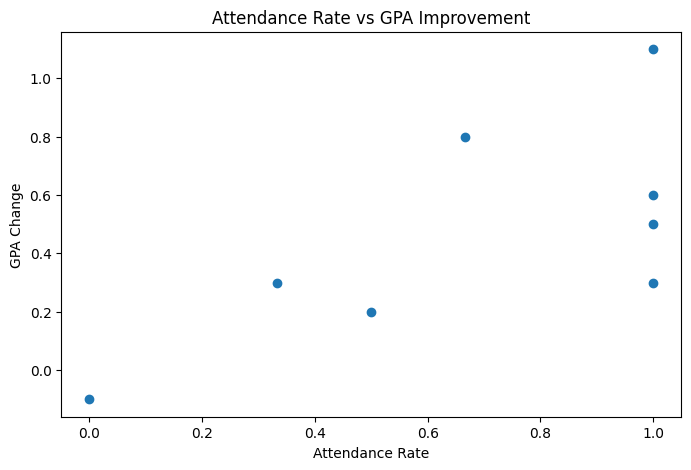

In [153]:
plt.figure(figsize=(8,5))

plt.scatter(
    evaluation_df["attendance_rate"],
    evaluation_df["gpa_change"]
)

plt.xlabel("Attendance Rate")
plt.ylabel("GPA Change")
plt.title("Attendance Rate vs GPA Improvement")

plt.show()

Participants who attended more consistently generally demonstrated greater academic improvement.

A positive relationship was observed between attendance rate and GPA improvement (r = 0.689).

Participation categories

In [154]:
conditions = [
    evaluation_df["attendance_rate"] >= 0.80,
    evaluation_df["attendance_rate"] >= 0.50
]

choices = [
    "High",
    "Medium"
]

evaluation_df["participation_level"] = np.select(
    conditions,
    choices,
    default="Low"
)

In [155]:
evaluation_df.groupby(
    "participation_level"
)["gpa_change"].mean()

,gpa_change
participation_level,
High,0.625
Low,0.100
Medium,0.500


In [156]:
evaluation_df.groupby(
    "participation_level"
)["participant_id"].count()

,participant_id
participation_level,
High,4
Low,9
Medium,2


There appears to be a positive relationship between participation and academic improvement.

Participants with:
* High participation improved GPA by an average of 0.625
* Medium participation improved GPA by an average of 0.500
* Low participation improved GPA by an average of 0.100


Participants with higher levels of program engagement demonstrated greater average academic improvement. High-participation participants showed an average GPA increase of 0.625 compared to 0.500 for medium-participation participants and 0.100 for low-participation participants. These findings suggest that sustained program participation may be associated with stronger academic outcomes.

This is a small data set and more data are needed for confirmation of these findings as well as to examine further:

"What can we do to move more participants into the High Participation category?"

Possible action items:
* Improve attendance reminders
* Increase transportation support
* Improve family communication
* Add incentives for consistent participation
* Identify barriers causing participants to drop attendance

In [157]:
evaluation_df.head()

,participant_id,name,birth_date,program,enrollment_date,status,gender,school,sessions_attended,attendance_rate,confidence_post,confidence_pre,confidence_change,pre_gpa,post_gpa,gpa_change,participation_level
0,101,Jane Smith,2010-03-02,Tutoring,2024-08-15,active,F,West High School,3.000,1.000,4.000,2.000,2.000,2.500,3.100,0.600,High
1,102,J Smith,2010-03-02,Tutoring,2024-08-15,active,F,West High School,1.000,0.333,4.000,3.000,1.000,2.700,3.000,0.300,Low
2,103,Marcus Lee,NaT,Mentoring,2024-09-01,active,M,Central High School,3.000,1.000,5.000,1.000,4.000,1.800,2.900,1.100,High
3,104,Sarah Johnson,2009-07-15,Mentoring,2024-09-05,active,F,East High School,3.000,1.000,5.000,4.000,1.000,3.200,3.500,0.300,High
4,105,Michael Brown,2008-12-03,Workforce Readiness,2024-09-15,active,M,North High School,1.000,0.500,3.000,2.000,1.000,2.400,2.600,0.200,Medium


# Dashboard creation

save dataframe to csv

In [159]:
evaluation_df.to_csv(
    "evaluation_dashboard_data.csv",
    index=False
)

Please go to:

 https://public.tableau.com/app/profile/susanna.hooper/viz/ProgramEvaluationPracticeProject/Sheet8$0

to View 4 Dashboard Visualizations of this project.

# Appendix

##Lessons Learned

### Keeping unique identifiers

## In ML Projects

You often remove IDs early:

```python
customer_id
participant_id
student_id
employee_id
```

because:

* They don't help predict outcomes.
* They can introduce noise.
* They may create data leakage.
* They have no meaningful relationship to the target variable.

So in an ML notebook, you might quickly do:

```python
X = df.drop(["participant_id"], axis=1)
```

and never think about it again.

---

## In Program Evaluation

The participant ID is sacred.

You protect it at all costs.

Because it is the key that allows you to answer questions like:

### Attendance

Did this participant attend?

### Survey

Did this participant improve?

### Outcomes

Did this participant's GPA increase?

### Retention

Did this participant stay enrolled?

### Reporting

How many unique participants were served?

---

Think about what happens if you drop participant_id now.

Suddenly you can't:

* Merge attendance
* Merge surveys
* Merge outcomes
* Identify duplicates
* Track longitudinal outcomes

The project falls apart.

---

## In Your Current Workflow

I would keep:

```python
participant_id
```

through:

### Audit

✓ Keep

### Cleaning

✓ Keep

### Standardization

✓ Keep

### Merging

✓ Keep

### Analysis

✓ Keep

### Dashboard Creation

Usually keep

---

## When Might We Remove It?

Possibly at the very end if creating:

### Summary Tables

Example:

| Program   | Avg GPA Improvement |
| --------- | ------------------- |
| Tutoring  | 0.42                |
| Mentoring | 0.31                |

No need for IDs there.

---

## Another Evaluation Concept

Many nonprofits actually have:

### Internal ID

```text
participant_id
```

and

### External Reporting ID

```text
reporting_id
```

or

```text
deidentified_id
```

so they can:

* protect privacy
* comply with funders
* comply with FERPA/HIPAA-like requirements

while still tracking outcomes.

That's why data stewardship is emphasized so heavily in the job description.

---

##Just Discovered

Ispent a lot of time learning:

* Decision Trees
* Random Forests
* XGBoost
* Neural Networks

But this project is exposing a different skill set:

### Data Evaluation

Questions become:

* Can I trust the data?
* Can I reconcile records?
* Can I track outcomes over time?
* Can I demonstrate program impact?
* Can I explain findings to leadership?

For this project, I would keep `participant_id` in every dataframe until we've cleaned, standardized, and merged everything. Only after analysis would we consider whether it needs to appear in any final reports or visualizations.


# Future Development

With more data, I'd like to explore predictive modeling to see if program participant drop-out can be precicted.